# Siparişler - `review_score` Çok Değişkenli Regresyonu

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

⚠️ Devam etmeden önce:
* 💾 Önceki ünitenin Siparişler çözümünü indirin
* 👥 `order_solution.py`'nin içeriğini `olist/order.py` dosyasına kopyalayıp yapıştırın

> ✅ **Not (Poi):** `olist/order.py` zaten tamam ve commit'li — bu adımı atlıyoruz.

⚠️ `olist` havuzunuzda `order.py` dosyasındaki kod değişikliklerini commit etmeyi unutmayın!

👇 Öncelikle `orders` veri setini içeri aktarın

In [3]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)
orders.head()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered,0,0,4,1,1,29.99,8.72,18.063837
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered,0,0,4,1,1,118.70,22.76,856.292580
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered,1,0,5,1,1,159.90,19.22,514.130333
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered,1,0,5,1,1,45.00,27.20,1822.800366
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered,1,0,5,1,1,19.90,8.72,30.174037


Önceki analizimizi hatırlayalım:

Korelasyon matrisinde `review_score` çoğunlukla `wait_time` ve `delay_vs_expected` ile ilişkili. Ancak bu iki özellik birbirleriyle de yüksek ilişkili.

Bu alıştırmada `statsmodels` ile bir özelliğin etkisini, **diğerlerini sabit tutarak** ayırt edeceğiz.

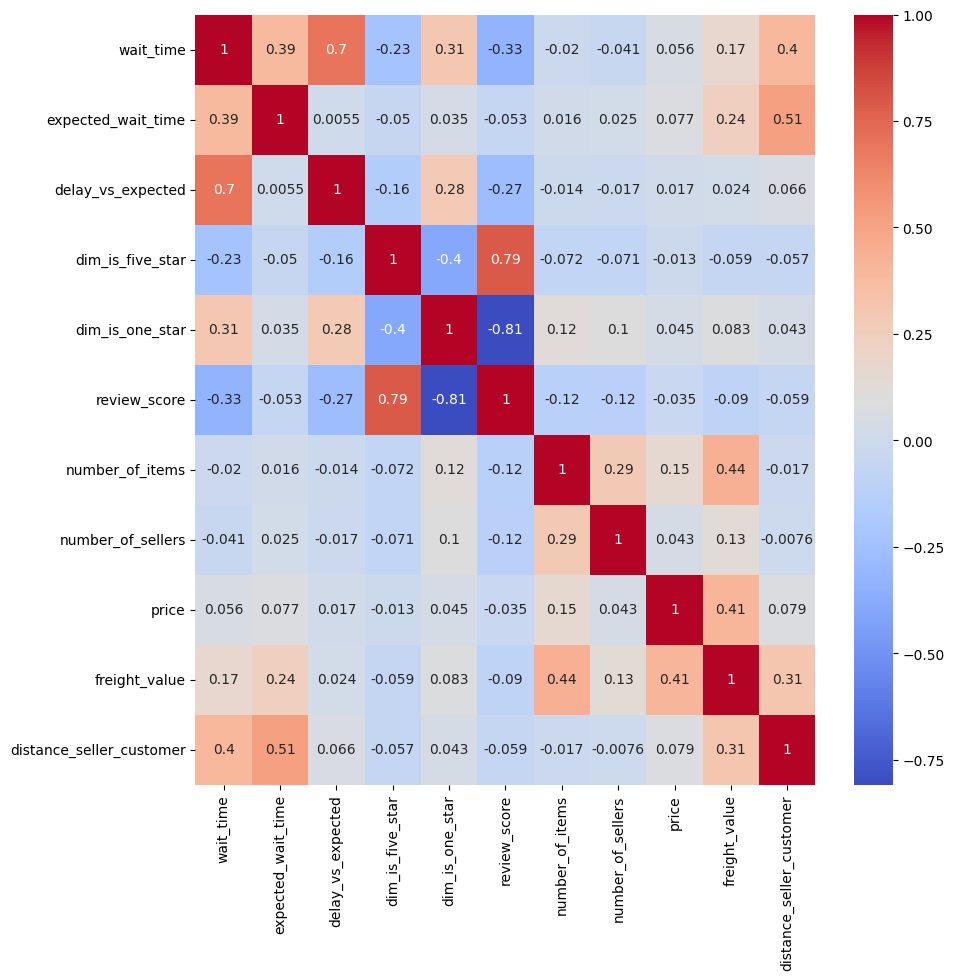

In [4]:
plt.figure(figsize = (10, 10))

sns.heatmap(
    orders.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    annot_kws={"size": 10}
);

## 1 - Tek Değişkenli Regresyon

❓ `statsmodels.formula.api` ile şunları oluşturun:
 - `model1`: `review_score` ~ `wait_time`
 - `model2`: `review_score` ~ `delay_vs_expected`

Her biri için `summary` yazdırın: `R-squared`, katsayılar, `t`, `p` ve `%95 güven aralıkları`.

***Model 1***:

In [5]:
model1 = smf.ols(formula='review_score ~ wait_time', data=orders).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                 1.204e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:43:30   Log-Likelihood:            -1.5439e+05
No. Observations:               95857   AIC:                         3.088e+05
Df Residuals:                   95855   BIC:                         3.088e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7237      0.006    727.863      0.000       4.711       4.736
wait_time     -0.0454      0.000   -109.747      0.000      -0.046      -0.045
==============================================================================
Omnibus:                    19550.278   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            35451.562
Skew:                          -1.300   Prob(JB):                         0.00
Kurtosis:                       4.453   Cond. No.                         26.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

***Model 2***:

In [6]:
model2 = smf.ols(formula='review_score ~ delay_vs_expected', data=orders).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     7681.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:43:31   Log-Likelihood:            -1.5637e+05
No. Observations:               95857   AIC:                         3.127e+05
Df Residuals:                   95855   BIC:                         3.128e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.2121      0.004   1041.068      0.000       4.204       4.220
delay_vs_expected    -0.0752      0.001    -87.644      0.000      -0.077      -0.073
==============================================================================
Omnibus:                    20658.144   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            49762.249
Skew:                          -1.203   Prob(JB):                         0.00
Kurtosis:                       5.582   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2 - Çok Değişkenli Regresyon

❓ `wait_time` sabit tutulduğunda, bir gün `delay_vs_expected` eklemenin `review_score` üzerindeki etkisi nedir? Hangisi düşük puanı daha çok açıklar?

`wait_time` ve `delay_vs_expected`'i bağımsız, `review_score`'u hedef alan `model3`'ü çalıştırın.

***Model 3***:

In [7]:
model3 = smf.ols(formula='review_score ~ wait_time + delay_vs_expected', data=orders).fit()
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     6193.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:43:31   Log-Likelihood:            -1.5424e+05
No. Observations:               95857   AIC:                         3.085e+05
Df Residuals:                   95854   BIC:                         3.085e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.6504      0.008    601.530      0.000       4.635       4.666
wait_time            -0.0383      0.001    -65.991      0.000      -0.039      -0.037
delay_vs_expected    -0.0205      0.001    -17.399      0.000      -0.023      -0.018
==============================================================================
Omnibus:                    19992.636   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            40507.460
Skew:                          -1.249   Prob(JB):                         0.00
Kurtosis:                       4.976   Cond. No.                         31.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

----
👉 Çok değişkenli regresyon bir özelliğin etkisini izole eder; bu katsayılara **kısmi korelasyon katsayıları** denir.

❓ *seaborn* basit regresyon katsayılarıyla fark var mı? `wait_time` ve `delay_vs_expected` göreceli eğimleri hakkında ne söylenir?

<details>
    <summary>- 💡 Solution 💡-</summary>

- Holding `wait_time` constant, each additional day of `delay` reduces the review_score on average by 0.0205 [0.023 - 0.018] points
- Holding `delay` constant, each additional day of `wait_time` reduces the review_score on average by 0.0383 [0.039 - 0.037] points

Contrary to the simple bivariate analysis, `delay` is actually less impactful than `wait_time` in driving lower `review_score`! Multi-variate regression removes the impact of confounding factors.

> 📝 **Yorum (Poi):**
> Basit (seaborn) regresyonda `delay` eğimi (≈ −0.10) `wait_time`'dan (≈ −0.05) dik görünüyordu.
> Çok değişkenli `model3`'te tablo **tersine dönüyor**: `wait_time` (≈ **−0.038**) `delay`'den (≈ **−0.020**) daha güçlü.
> Neden? İki değişken birbiriyle yüksek korelasyonlu — basit regresyonda `delay`, `wait_time`'ın etkisini de üstleniyordu.
> İkisini aynı modele koyunca etki **paylaşılıyor** ve gerçek sürücünün toplam bekleme süresi olduğu ortaya çıkıyor.
> Bu, tam olarak görevin uyardığı **karıştırıcı (confounding)** etkisinin sayısal kanıtı.

---
❌ R-squared düşük: review_score varyasyonunun en fazla ~%12'si bu iki özellikle açıklanıyor.

✅ Açıklanabilirliği artırmak için daha fazla özellik ekleyelim (`model4`).

📝 <u>Not</u>: **Çok Değişkenli Doğrusal Regresyon** = **Ordinary Least Squares**; **MSE**'yi minimize eder.

***Model 4***:

❓ Hangi özellikleri seçersiniz? Bir `features` DataFrame oluşturun.

- ⚠️ **veri sızıntısı** yok: `review_score`'tan türetilen özellikleri ekleme (`dim_is_five_star`, `dim_is_one_star`)
- ⚠️ Birbiriyle mükemmel korelasyonlu iki özellik ekleme

In [8]:
# Feature set: drop the target and anything derived from it (leakage),
# plus the non-numeric id/status columns.
features = orders.drop(columns=[
    'review_score',        # the target
    'dim_is_five_star',    # derived from review_score -> leakage
    'dim_is_one_star',     # derived from review_score -> leakage
    'order_id',            # identifier, not a feature
    'order_status'         # constant ('delivered') after filtering
])
features.head()

,wait_time,expected_wait_time,delay_vs_expected,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,8.436574,15.544063,0.0,1,1,29.99,8.72,18.063837
1,13.782037,19.137766,0.0,1,1,118.70,22.76,856.292580
2,9.394213,26.639711,0.0,1,1,159.90,19.22,514.130333
3,13.208750,26.188819,0.0,1,1,45.00,27.20,1822.800366
4,2.873877,12.112049,0.0,1,1,19.90,8.72,30.174037


Sonra özellikleri **standardize** edeceğiz (z-score $Z_i = \frac{X_i - \mu_i}{\sigma_i}$).

**Neden?** Ölçek farkları yüzünden bazı özellikler yapay olarak daha önemli görünür. Katsayıları karşılaştırılabilir yapmak için aynı ölçeğe getiririz.

👉 Adımlar: `features`'tan başla → `mean` çıkar → `std`'ye böl → `orders_standardized`'e kaydet → `review_score`'u ekle.

In [9]:
# z-score each feature. NOTE: parentheses matter -
# (X - mean) / std, NOT X - mean/std (the hint's precedence is wrong)
orders_standardized = (features - features.mean()) / features.std()

# Add the (un-standardized) target back for the formula
orders_standardized['review_score'] = orders['review_score']
orders_standardized.head()

,wait_time,expected_wait_time,delay_vs_expected,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer,review_score
0,-0.431145,-0.934710,-0.16178,-0.264601,-0.112553,-0.513781,-0.652014,-0.979487,4
1,0.134233,-0.524724,-0.16178,-0.264601,-0.112553,-0.086645,0.000447,0.429765,4
2,-0.329857,0.331133,-0.16178,-0.264601,-0.112553,0.111732,-0.164063,-0.145487,5
3,0.073598,0.279693,-0.16178,-0.264601,-0.112553,-0.441509,0.206781,2.054683,5
4,-1.019499,-1.326250,-0.16178,-0.264601,-0.112553,-0.562364,-0.652014,-0.959127,5


👉 `model4`'ü oluşturun ve eğitin.

In [10]:
# Build the formula: review_score ~ all standardized features
feature_names = [c for c in orders_standardized.columns if c != 'review_score']
formula = 'review_score ~ ' + ' + '.join(feature_names)

model4 = smf.ols(formula=formula, data=orders_standardized).fit()
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     2084.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:43:31   Log-Likelihood:            -1.5238e+05
No. Observations:               95857   AIC:                         3.048e+05
Df Residuals:                   95848   BIC:                         3.049e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.1555      0.004   1084.635      0.000       4.148       4.163
wait_time                   -0.4878      0.007    -72.772      0.000      -0.501      -0.475
expected_wait_time           0.0916      0.005     18.897      0.000       0.082       0.101
delay_vs_expected           -0.0163      0.006     -2.722      0.006      -0.028      -0.005
number_of_items             -0.1287      0.004    -28.675      0.000      -0.137      -0.120
number_of_sellers           -0.1348      0.004    -33.623      0.000      -0.143      -0.127
price                       -0.0034      0.004     -0.800      0.424      -0.012       0.005
freight_value               -0.0012      0.005     -0.240      0.810      -0.011       0.009
distance_seller_customer     0.0681      0.005     14.050      0.000       0.059       0.078
==============================================================================
Omnibus:                    18724.569   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            36910.942
Skew:                          -1.186   Prob(JB):                         0.00
Kurtosis:                       4.901   Cond. No.                         3.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

---
❓ En önemli özellikler? (`.plot(kind='barh')` ile çubuk grafik)
- Genel performans nasıl değişti?
- Regresyon istatistiksel olarak anlamlı mı?

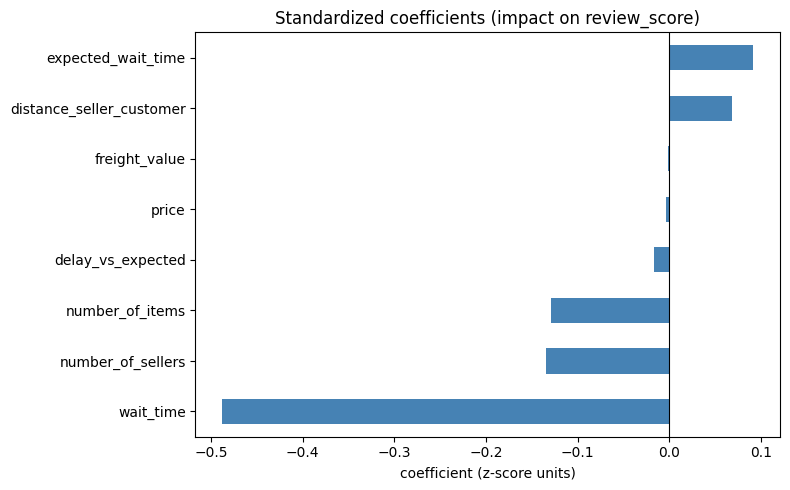

R-squared: 0.1482
F p-value: 0.00e+00


In [11]:
# Drop the intercept; sort coefficients by magnitude for a clean ranking
coefs = model4.params.drop('Intercept').sort_values()

coefs.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Standardized coefficients (impact on review_score)')
plt.xlabel('coefficient (z-score units)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"R-squared: {model4.rsquared:.4f}")
print(f"F p-value: {model4.f_pvalue:.2e}")

<details>
    <summary>- 💡 Açıklamalar 💡 -</summary>

- `wait_time` en büyük açıklayıcı değişkendir
- Bir siparişte ne kadar çok `items` ve `sellers` varsa `review_score` o kadar düşük
- Mesafe de rol oynar
- `price` / `freight_value` p-değerleri çok yüksekse sonuç çıkarılamayabilir

- F-istatistiği 1'den çok büyük → regresyon istatistiksel olarak anlamlı
- R-squared çok artmadı → açıklamanın çoğu orders veri seti dışında

⚠️ n >> p olduğunda düşük R-squared yaygındır; anlamlı olduğu sürece içgörü yine de geçerlidir.
</details>

## 3 - Model Performansını Kontrol Edin

⚠️ Performans sadece R-squared ile ölçülmez!

👀 Tahminlerin ve özellikle **kalıntıların** dağılımını her zaman görselleştirin.

❓ Kalıntıları hesaplayın. Ortalamaları ≈ 0 olmalı.

In [12]:
# Residual = actual - predicted
predicted_review_score = model4.predict(orders_standardized)
residuals = orders_standardized['review_score'] - predicted_review_score

print(f"Mean of residuals: {residuals.mean():.2e}")   # ~0, as expected for OLS

Mean of residuals: -1.48e-14


🧮 İlişkili RMSE'yi hesaplayın.

In [13]:
# RMSE = sqrt(mean(residual^2))
rmse = np.sqrt((residuals ** 2).mean())
print(f"RMSE: {rmse:.4f}")

RMSE: 1.1861


📊 `residuals`'ı bir histogramda çizin.

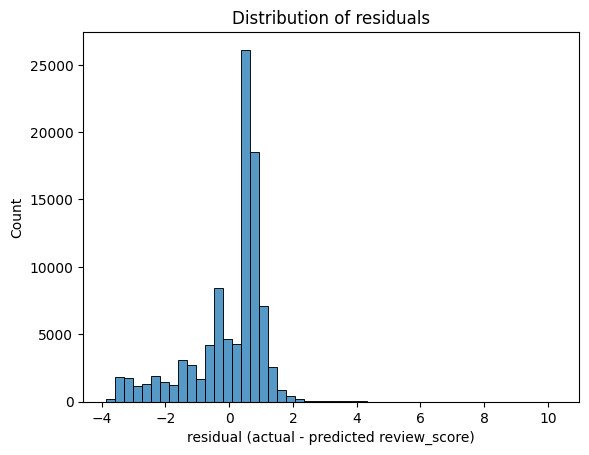

In [14]:
sns.histplot(residuals, bins=50)
plt.title('Distribution of residuals')
plt.xlabel('residual (actual - predicted review_score)')
plt.show()

❓ Kalıntıların şekli neden garip?

*İpucu:* Aynı grafikte `review_score` ile `predicted_review_score` dağılımlarını çizin.

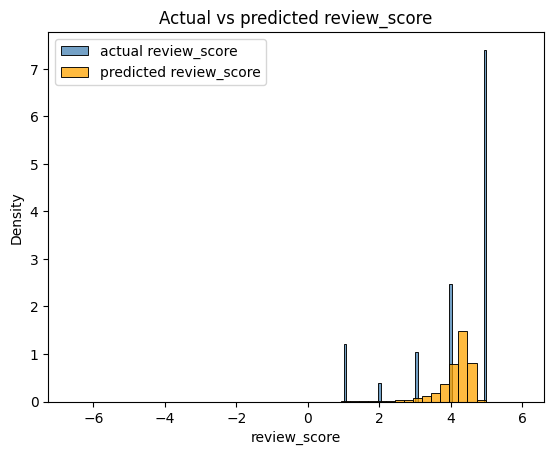

In [15]:
# Actual is 5 discrete spikes (1-5); predicted is a narrow continuous blob.
# Their difference => several overlapping shifted humps => the 'weird' shape.
sns.histplot(orders_standardized['review_score'], bins=50,
             color='steelblue', label='actual review_score', stat='density')
sns.histplot(predicted_review_score, bins=50,
             color='orange', label='predicted review_score', stat='density')
plt.legend()
plt.title('Actual vs predicted review_score')
plt.show()

📈 Önceki challenge'ın regresyon çizgisini yeniden çizelim:

(0.0, 5.9317873071772)

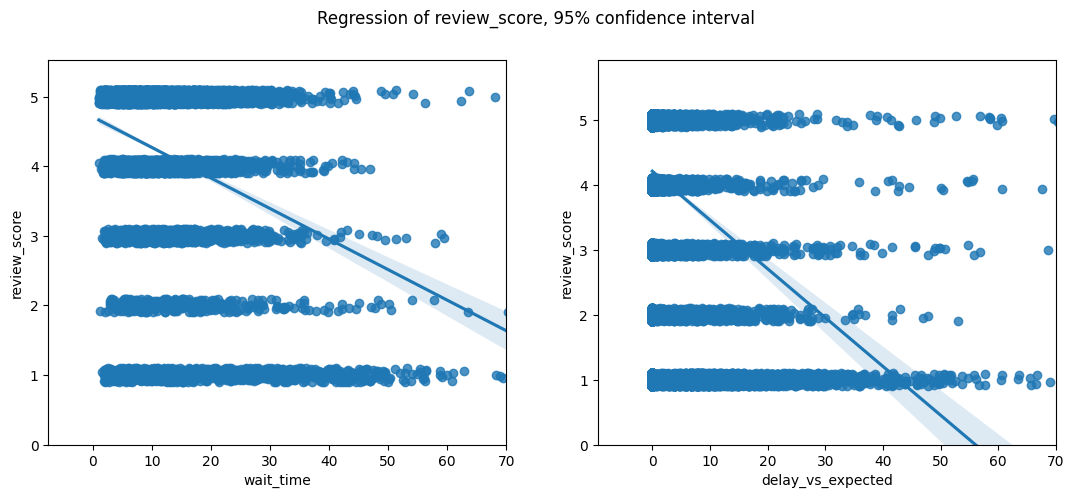

In [16]:
sample = orders.sample(10000, random_state=42)
plt.figure(figsize=(13,5))
plt.suptitle('Regression of review_score, 95% confidence interval')
plt.subplot(1,2,1)
sns.regplot(x = sample.wait_time, y= sample.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

plt.subplot(1,2,2)
sns.regplot(x = orders.delay_vs_expected, y= orders.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

☝️ `review_score` ayrı bir sayı (1–5) ve aynı zamanda kategori olduğu için doğrusal regresyon zorlanıyor.

📅 Sonraki ünite: adına rağmen bir **sınıflandırma** algoritması olan **Logistic Regression**.

☝️ Sonuç: model iki nedenle zayıf — (1) yeterli özellik yok (düşük R²), (2) doğrusal regresyonu ayrık bir sınıflandırma problemine uyduruyoruz.

💡 Sonraki challenge'da analizi **satıcı seviyesine** toplayacağız.

🏁 Harika iş!

💾 Notebook'u *kaydet*, *commit* ve *push* etmeyi unutma!